In [111]:
import pandas as pd
import ast

In [112]:
# match 데이터는 전부 저런 형식임
# 그렇기 때문에 for loop를 통해 match 데이터들을 수정

In [113]:
# import pandas as pd
# import ast

# file_paths = [
#     '../../collected_data/match-solo-rank.csv',
#     '../../collected_data/match-clan-rank.csv',
#     '../../collected_data/match-normal-individual.csv',
#     '../../collected_data/match-quick-clan.csv'
# ]

# for file_path in file_paths:
#     # 불러오기
#     df = pd.read_csv(file_path)

#     # match 컬럼 문자열을 리스트로 변환
#     df['match'] = df['match'].apply(
#         lambda x: ast.literal_eval(x) if pd.notnull(x) and x != '[]' else []
#     )

#     # explode
#     df_exploded = df.explode('match')

#     # match 딕셔너리를 컬럼으로 확장
#     match_df = pd.json_normalize(df_exploded['match'])

#     
#     match_df['ouid'] = df_exploded['ouid'].values

#     # 덮어쓰기
#     match_df.to_csv(file_path, index=False, encoding='utf-8-sig')

#     print(f"{file_path}")

In [114]:
df_match_solo_rank = pd.read_csv('../../collected_data/match-solo-rank.csv')
df_match_clan_rank = pd.read_csv('../../collected_data/match-clan-rank.csv')
df_match_normal = pd.read_csv('../../collected_data/match-normal-individual.csv')
df_match_quick_clan = pd.read_csv('../../collected_data/match-quick-clan.csv')

In [115]:
df_match_clan_rank.shape, df_match_normal.shape, df_match_quick_clan.shape, df_match_solo_rank.shape

((54543, 9), (146863, 9), (235070, 9), (209712, 9))

In [116]:
df_list = [df_match_normal, df_match_clan_rank, df_match_quick_clan, df_match_solo_rank]

for df in df_list:
    df['date_match'] = pd.to_datetime(df['date_match']).dt.date

In [117]:
df_match_clan_rank.head(1)

,match_id,match_type,match_mode,date_match,match_result,kill,death,assist,ouid
0,2.507270e+17,클랜 랭크전,폭파미션,2025-07-26,1.0,2.0,4.0,1.0,9b2852e25a85deebc5ce4173b1ccc1e6


In [118]:
df_match_normal.head(1)

,match_id,match_type,match_mode,date_match,match_result,kill,death,assist,ouid
0,2.507260e+17,일반전,개인전,2025-07-25,2.0,22.0,29.0,0.0,9b2852e25a85deebc5ce4173b1ccc1e6


In [119]:
df_match_quick_clan.head(1)

,match_id,match_type,match_mode,date_match,match_result,kill,death,assist,ouid
0,2.507292e+17,퀵매치 클랜전,폭파미션,2025-07-29,1.0,12.0,6.0,2.0,9b2852e25a85deebc5ce4173b1ccc1e6


In [120]:
df_match_solo_rank.head(1)

,match_id,match_type,match_mode,date_match,match_result,kill,death,assist,ouid
0,2.507292e+17,랭크전 솔로,폭파미션,2025-07-29,2.0,0.0,3.0,0.0,9b2852e25a85deebc5ce4173b1ccc1e6


C:\Users\jjong\AppData\Local\Temp\ipykernel_7776\3363959576.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('GnBu_r')


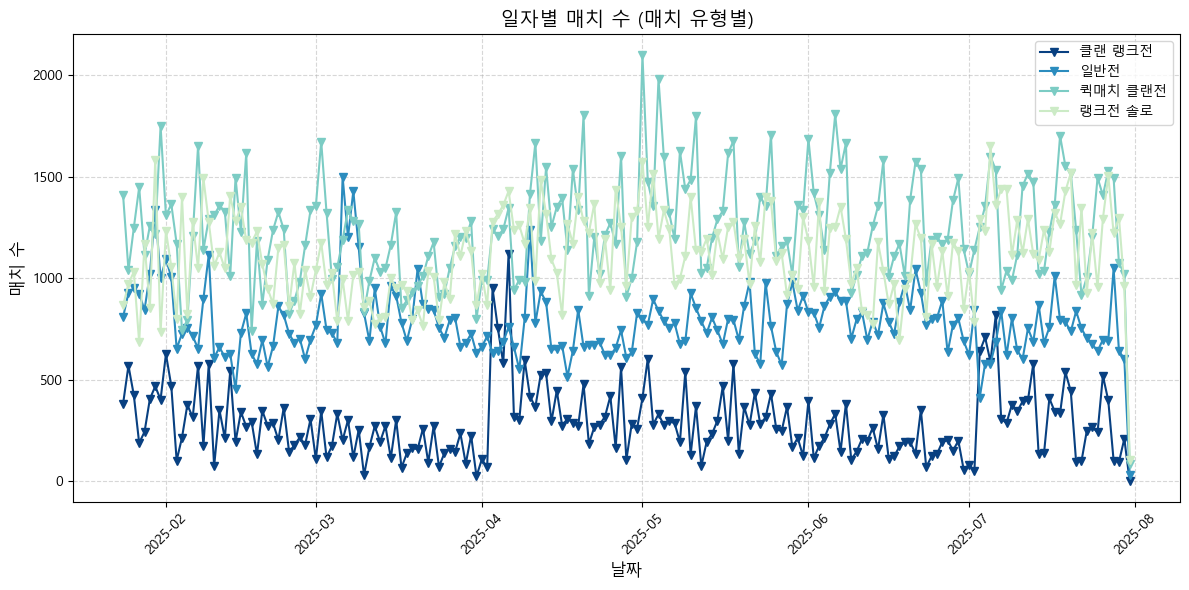

In [121]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.font_manager as fm
import matplotlib.colors as mcolors

# 한글 폰트 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 매치 데이터프레임과 라벨
df_list = [
    (df_match_clan_rank, '클랜 랭크전'),
    (df_match_normal, '일반전'),
    (df_match_quick_clan, '퀵매치 클랜전'),
    (df_match_solo_rank, '랭크전 솔로')
]

# GnBu 개취
cmap = cm.get_cmap('GnBu_r')
num_lines = len(df_list)
colors = [cmap(i / num_lines) for i in range(num_lines)]

# 그래프 그리기
plt.figure(figsize=(12, 6))

for idx, (df, label) in enumerate(df_list):
    counts = df['date_match'].value_counts().sort_index()
    plt.plot(counts.index, counts.values, marker='v', label=label, color=colors[idx])


plt.title('일자별 매치 수 (매치 유형별)', fontsize=14)
plt.xlabel('날짜', fontsize=12)
plt.ylabel('매치 수', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\jjong\AppData\Local\Temp\ipykernel_7776\1811062902.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('GnBu_r')


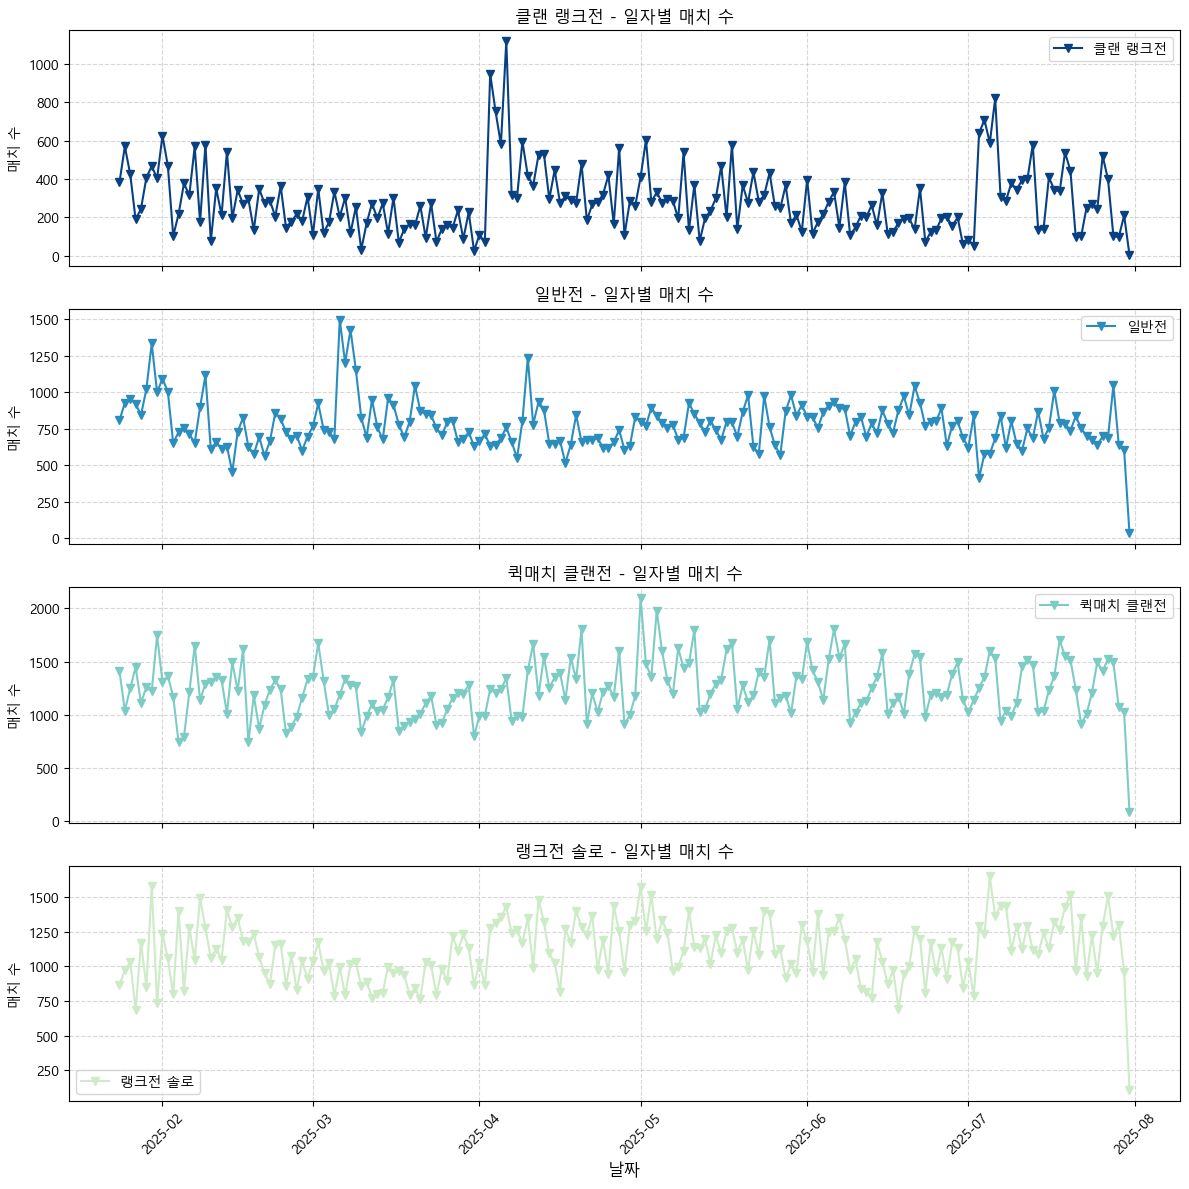

In [122]:
# 서브플롯으로 나눠서 그려보기
n = len(df_list)
fig, axes = plt.subplots(n, 1, figsize=(12, 3 * n), sharex=True)

# 색상 (GnBu로 그려보기 개취)
cmap = cm.get_cmap('GnBu_r')
colors = [cmap(i / n) for i in range(n)]

# 각 그래프 그리기
for idx, (df, label) in enumerate(df_list):
    ax = axes[idx]
    counts = df['date_match'].value_counts().sort_index()
    ax.plot(counts.index, counts.values, color=colors[idx], marker='v', label=label)

    ax.set_title(f"{label} - 일자별 매치 수", fontsize=12)
    ax.set_ylabel('매치 수')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

plt.xlabel('날짜', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 모드별 일별 평균 매치 수 변화 분석

1. 일자별 매치 수 집계
2. 시계열 형태로 병합
3. 이동평균 시각화 하기

In [123]:
# 일자별 매치 수 (시계열)
clan_rank_ts = df_match_clan_rank['date_match'].value_counts().sort_index()
normal_ts = df_match_normal['date_match'].value_counts().sort_index()
quick_clan_ts = df_match_quick_clan['date_match'].value_counts().sort_index()
solo_rank_ts = df_match_solo_rank['date_match'].value_counts().sort_index()

In [124]:
df_daily_match = pd.DataFrame({
    '클랜 랭크전': clan_rank_ts,
    '일반전': normal_ts,
    '퀵매치 클랜전': quick_clan_ts,
    '랭크전 솔로': solo_rank_ts
}).fillna(0)

# 날짜 오름차순 정렬
df_daily_match.index = pd.to_datetime(df_daily_match.index)
df_daily_match = df_daily_match.sort_index()

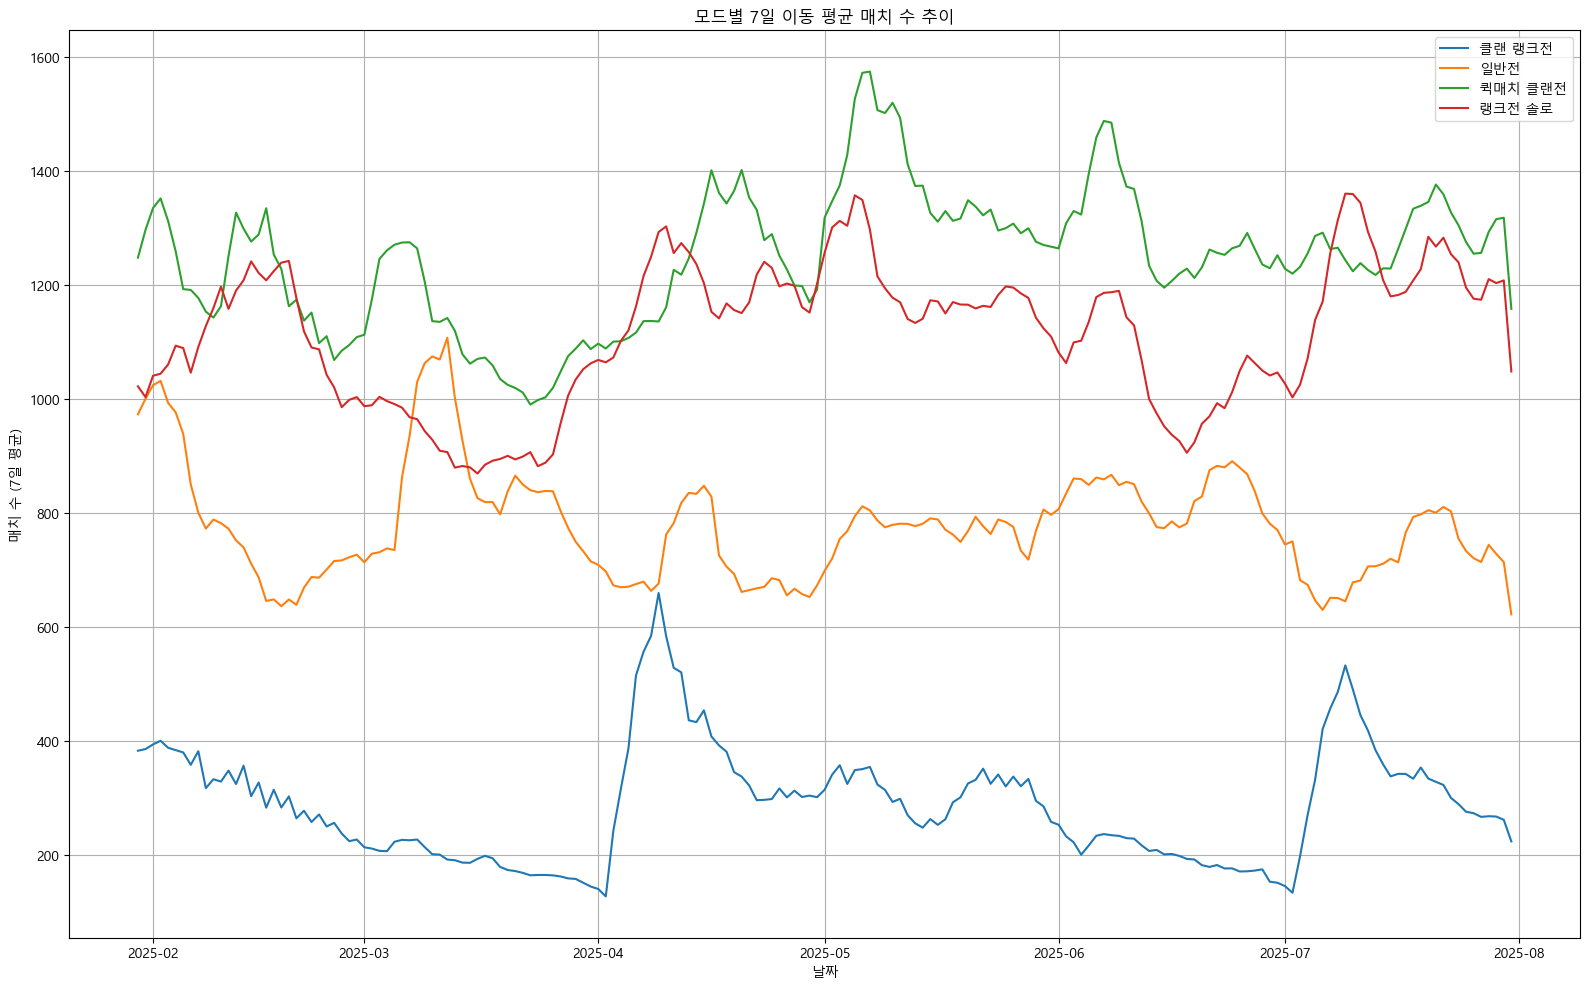

In [125]:
plt.figure(figsize=(16, 10))
for col in df_daily_match.columns:
    plt.plot(df_daily_match.index, df_daily_match[col].rolling(7).mean(), label=col)

plt.title('모드별 7일 이동 평균 매치 수 추이')
plt.xlabel('날짜')
plt.ylabel('매치 수 (7일 평균)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [126]:
# 그렇다면 주중 vs 주말을 비교해보면 어떨지 궁금

df_daily_match['dayofweek'] = df_daily_match.index.dayofweek
df_daily_match['is_weekend'] = df_daily_match['dayofweek'].isin([5, 6])

# 주중/주말 평균 비교
df_daily_match.groupby('is_weekend').mean().T

is_weekend,False,True
클랜 랭크전,258.118519,361.055556
일반전,748.148148,848.037037
퀵매치 클랜전,1169.385185,1427.722222
랭크전 솔로,1054.518519,1244.851852
dayofweek,2.000000,5.500000


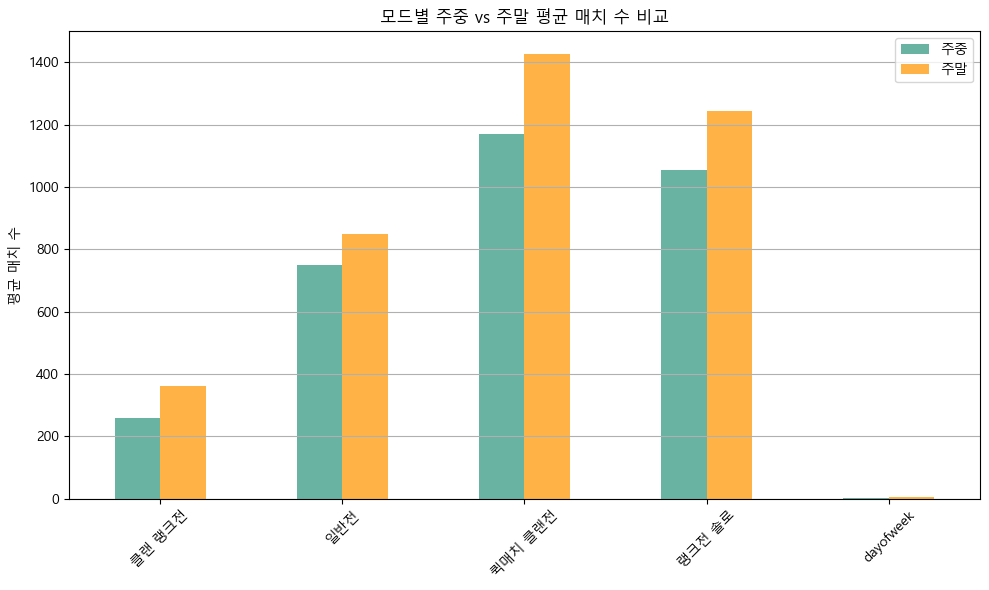

In [127]:
mean_week = df_daily_match.groupby('is_weekend').mean().T
mean_week.columns = ['주중', '주말']

mean_week.plot(kind='bar', figsize=(10, 6), color=['#69b3a2', '#ffb347'])
plt.title('모드별 주중 vs 주말 평균 매치 수 비교')
plt.ylabel('평균 매치 수')
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [128]:
# 그렇다면 요일별 비교는?

df_daily_match['dayofweek'] = df_daily_match.index.dayofweek

In [129]:
# 요일별 평균 매치 수
mean_by_day = df_daily_match.groupby('dayofweek').mean().drop(columns=['is_weekend'])
mean_by_day.index = ['월', '화', '수', '목', '금', '토', '일'] 

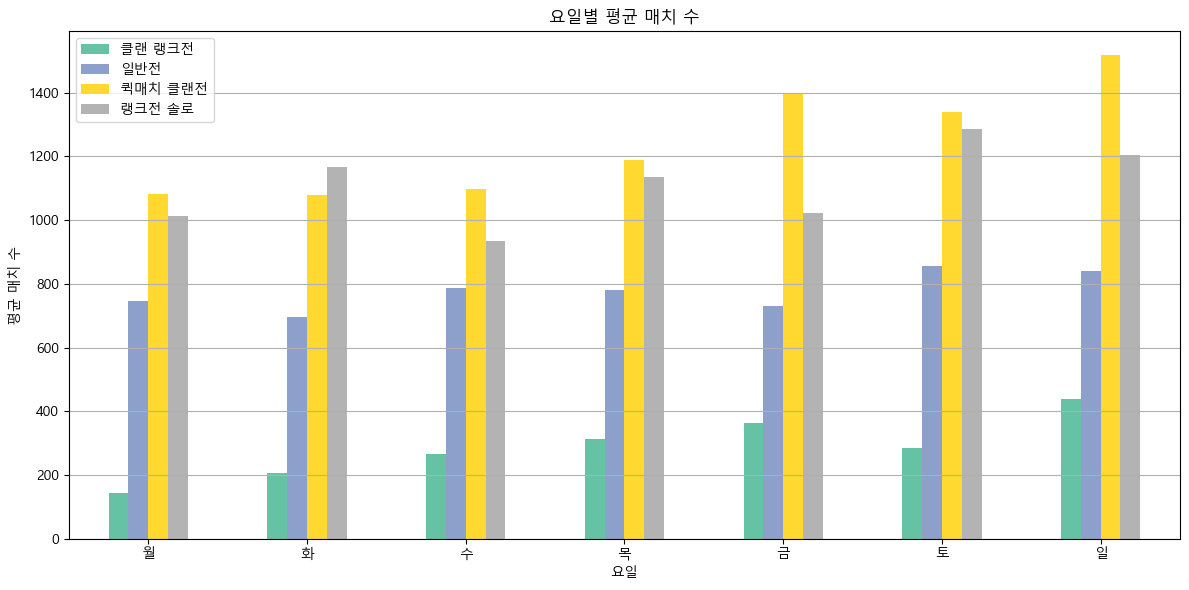

In [130]:
plt.figure(figsize=(12, 6))
mean_by_day.plot(kind='bar', ax=plt.gca(), colormap='Set2')

plt.title('요일별 평균 매치 수')
plt.ylabel('평균 매치 수')
plt.xlabel('요일')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


## 📊 모드별 매치 수 분석 요약

### ✅ 1. 모드별 7일 이동 평균 매치 수 추이

- **랭크전 솔로**와 **퀵매치 클랜전**은 전체 기간 동안 가장 활발하게 플레이된 인기 모드로, 뚜렷한 주기성을 보이며 꾸준한 수요를 유지하고 있음.
- **일반전**은 비교적 낮은 매치 수를 보이지만 변동성이 적고 일정한 수치를 유지.
- **클랜 랭크전**은 전체적으로 낮은 수치를 보이나, 특정 구간(예: 4월, 7월 초)에 급격한 증가가 나타나 이벤트성 콘텐츠로 활용되고 있을 가능성이 큼.

---

### ✅ 2. 주중 vs 주말 평균 매치 수 비교

- 전 모드 공통적으로 **주말의 평균 매치 수가 주중보다 높음**.
- 특히 **퀵매치 클랜전**과 **랭크전 솔로**는 주말에 15~20% 이상 매치 수가 증가하여 주말 플레이 선호도가 높음을 나타냄.
- **클랜 랭크전**은 전체 모드 중 매치 수가 가장 낮지만, 주말에는 평일 대비 약 40% 이상 상승하여 **클랜 활동이 주말에 집중**됨을 확인할 수 있음.

---

### ✅ 3. 요일별 평균 매치 수 분석

- **일요일**에 전 모드의 매치 수가 가장 높으며, **토요일** 역시 고르게 높음 → 유저의 주말 몰림 현상 뚜렷.
- **랭크전 솔로**는 **화요일**에도 평균이 높게 나타났는데, 이는 점검 이후 콘텐츠 초기화나 보상 지급일과 같은 **시스템 이벤트**의 영향일 가능성 있음.
- **클랜 랭크전**은 금~일 집중형 패턴을 보이며, 주 초반에는 플레이 빈도가 현저히 낮음.

---

### 🧩 종합 해석 및 시사점

| 항목              | 요약 |
|------------------|------|
| 🔥 인기 모드         | 랭크전 솔로, 퀵매치 클랜전 |
| 📉 비교적 저조한 모드 | 일반전 |
| 🎯 주말 특화 콘텐츠   | 클랜 랭크전 |
| 📅 주목 요일        | 일요일(최고), 토요일(강세), 화요일(이벤트 가능성) |
| 💡 운영 인사이트     |  
- 주말 보상, 랭크 콘텐츠 집중 운영  
- 일반전은 신규 유저용 캐주얼 채널로 유지  
- 클랜 랭크전은 시즌제·이벤트와의 연동 강화 필요해 보임



### 모드 별로 인기도 비교

- df_daily_match 데이터를 그대로 활용해서 분석

In [131]:
df_daily_match

,클랜 랭크전,일반전,퀵매치 클랜전,랭크전 솔로,dayofweek,is_weekend
date_match,,,,,,
2025-01-24,383,809,1408,866,4,False
2025-01-25,570,928,1040,972,5,True
2025-01-26,425,952,1248,1032,6,True
2025-01-27,189,923,1448,685,0,False
2025-01-28,244,844,1114,1168,1,False
...,...,...,...,...,...,...
2025-07-27,399,691,1529,1505,6,True
2025-07-28,103,1049,1493,1222,0,False
2025-07-29,96,642,1073,1298,1,False


In [132]:
# 각 날짜별로 매치가 많이 진행된 모드 추출
df_daily_match['most_popular_mode'] = df_daily_match[['클랜 랭크전', '일반전', '퀵매치 클랜전', '랭크전 솔로']].idxmax(axis=1)


In [133]:
df_daily_match['most_popular_mode'].value_counts()

most_popular_mode
퀵매치 클랜전    126
랭크전 솔로      60
일반전          3
Name: count, dtype: int64

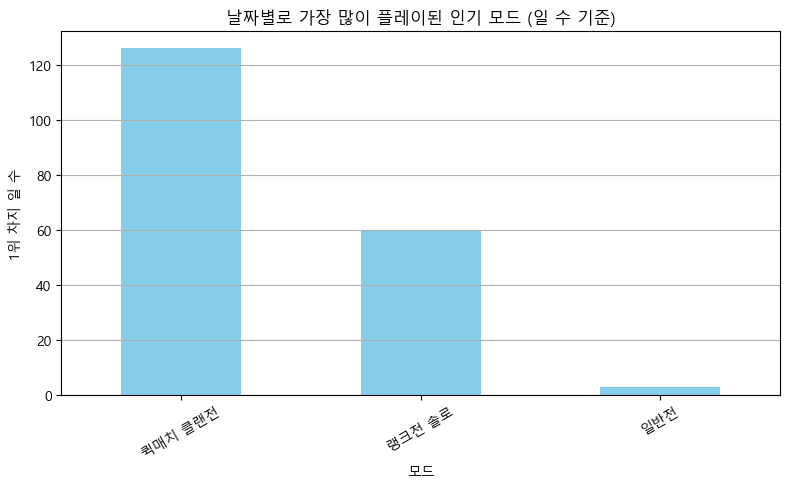

In [134]:
# 가장 많이하는 게임 모드가 어떤 모드인지 시각화
popular_counts = df_daily_match['most_popular_mode'].value_counts()

# 시각화
plt.figure(figsize=(8, 5))
popular_counts.plot(kind='bar', color='skyblue')
plt.title('날짜별로 가장 많이 플레이된 인기 모드 (일 수 기준)')
plt.ylabel('1위 차지 일 수')
plt.xlabel('모드')
plt.xticks(rotation=30)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


<Axes: title={'center': '가장 인기 있었던 모드 (1위 차지 일수 기준)'}, xlabel='most_popular_mode'>

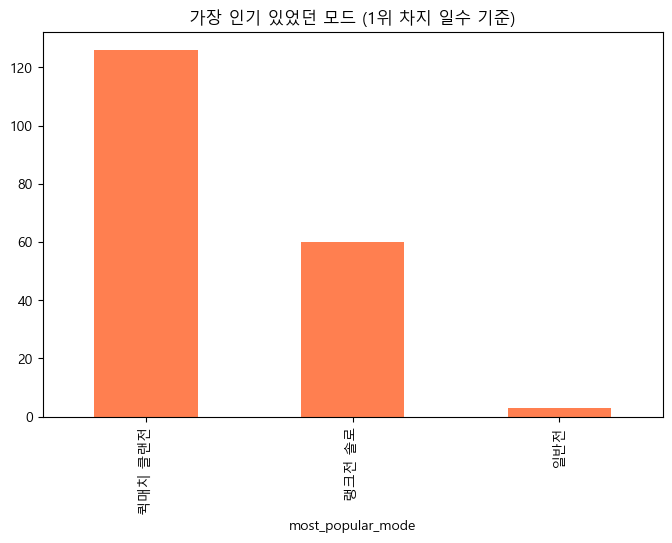

In [135]:
# 각 모드가 1위를 차지한 날짜 수
df_daily_match['most_popular_mode'].value_counts().plot(
    kind='bar', color='coral', title='가장 인기 있었던 모드 (1위 차지 일수 기준)', figsize=(8, 5)
)


### 모드별 킬/데스/어시스트 비율 분석

- 과연 모드별로 kda 지표가 다를까??

#### 통계 분석 방향

- 평균 차이 검정 - **<span style="color:orange">Kruskal-Wallis</span>**
    - 비정규, 비등분산 데이터에 대한 검정 방법

In [136]:
# 안전하게 분모가 0이 되는 경우 방지
def compute_kda(df):
    df = df.copy()
    df['KDA'] = (df['kill'] + df['assist']) / df['death'].replace(0, 1)
    return df

df_clan_rank_kda = compute_kda(df_match_clan_rank)
df_normal_kda = compute_kda(df_match_normal)
df_quick_clan_kda = compute_kda(df_match_quick_clan)
df_solo_rank_kda = compute_kda(df_match_solo_rank)

In [137]:
# 모드별 kda 값을 하나의 데이터프레임으로 통합

df_kda = pd.concat([
    df_clan_rank_kda[['ouid', 'KDA']].assign(mode='클랜 랭크전'),
    df_normal_kda[['ouid', 'KDA']].assign(mode='일반전'),
    df_quick_clan_kda[['ouid', 'KDA']].assign(mode='퀵매치 클랜전'),
    df_solo_rank_kda[['ouid', 'KDA']].assign(mode='랭크전 솔로'),
])

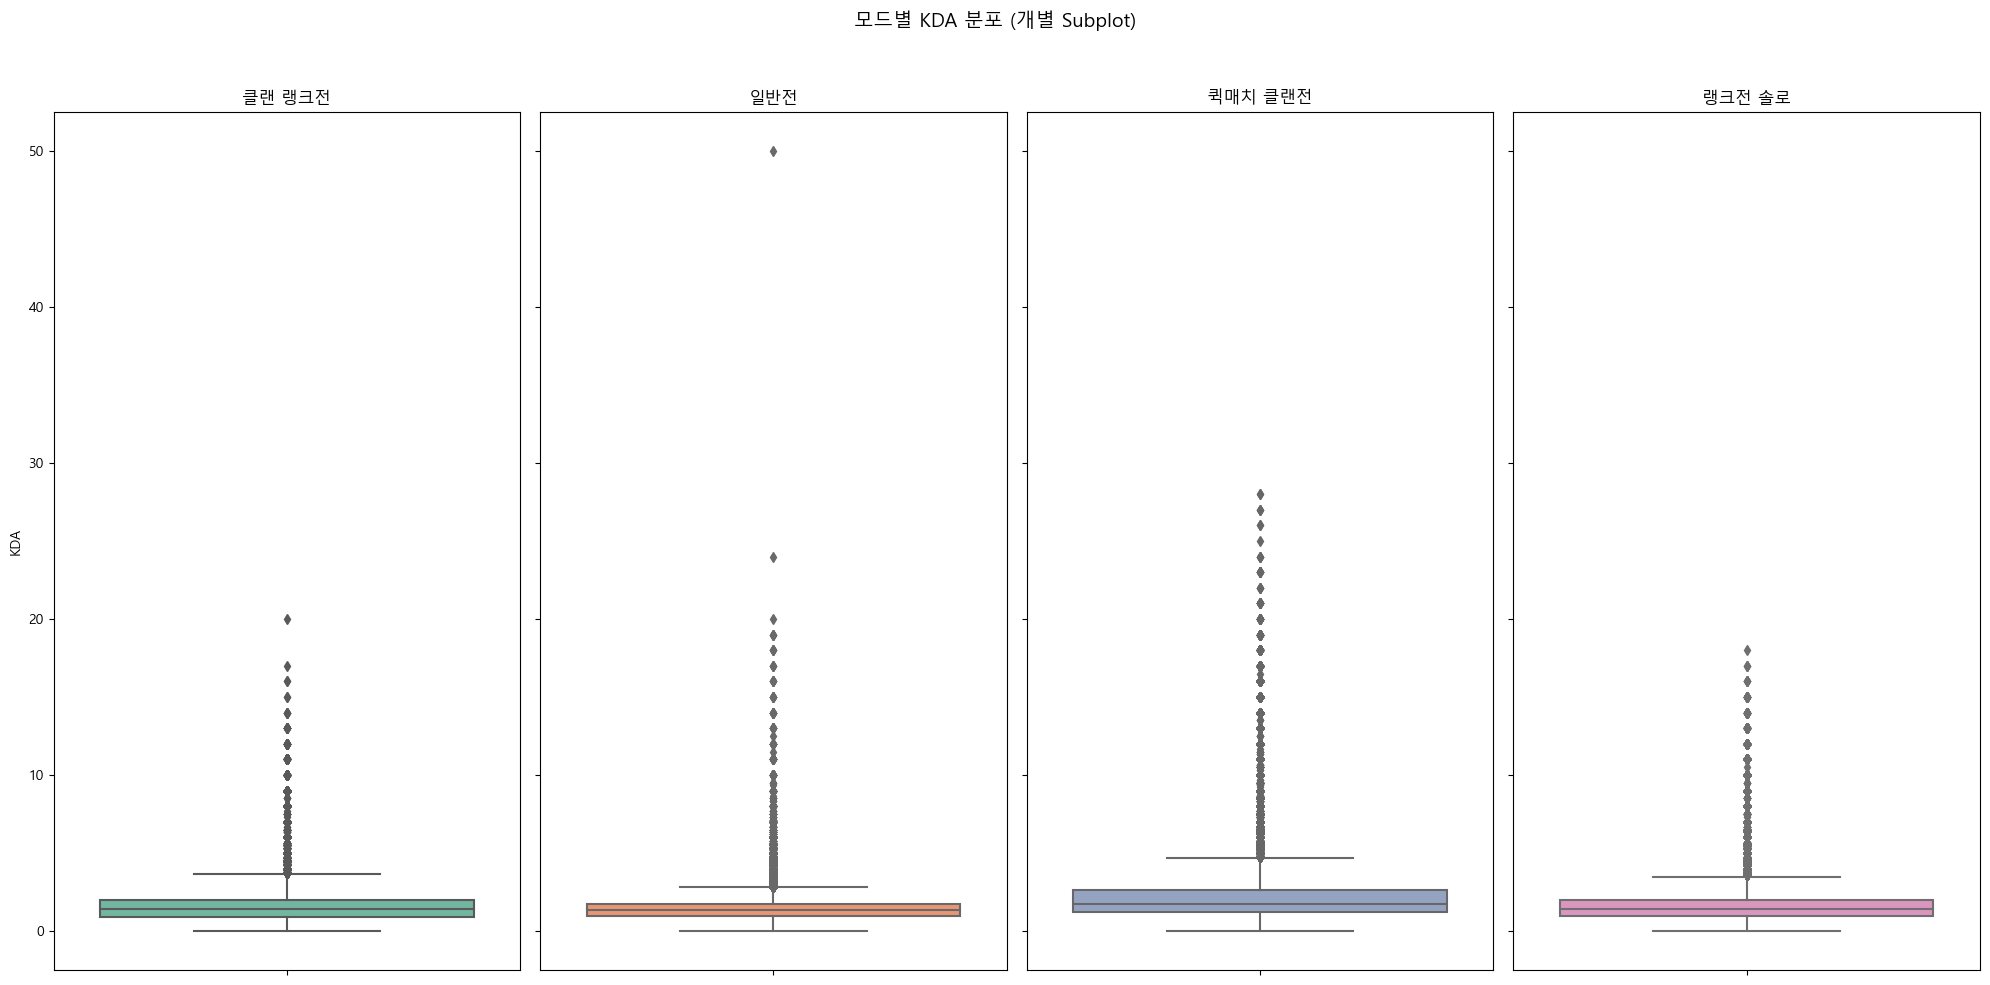

In [138]:
import seaborn as sns

# 모드 리스트
modes = df_kda['mode'].unique()

# subplot 설정
fig, axes = plt.subplots(1, len(modes), figsize=(20, 10), sharey=True)

# 각 모드별 boxplot
for i, mode in enumerate(modes):
    sns.boxplot(
        data=df_kda[df_kda['mode'] == mode],
        y='KDA',
        ax=axes[i],
        color=sns.color_palette('Set2')[i]
    )
    axes[i].set_title(mode)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('KDA' if i == 0 else '')

plt.suptitle('모드별 KDA 분포 (개별 Subplot)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## 🎯 모드별 KDA 분포 분석 (Boxplot)

### ✅ 분석 목적
각 게임 모드에서의 **KDA (Kill + Assist / Death)** 분포를 시각화하여,
모드별 플레이 성향, 난이도, 전투 패턴의 차이를 파악하고자 함.

---

### 📊 시각화 결과 (Subplot)

- 아래는 모드별 KDA를 개별 subplot으로 나타낸 boxplot이다.
- 모든 모드는 동일한 Y축 범위를 공유하므로 **비교가 직관적**이다.

| 게임 모드         | 관찰 내용 요약 |
|------------------|----------------|
| **클랜 랭크전**     | 전체적으로 낮은 KDA 분포, 중앙값도 낮고 비교적 안정적 |
| **일반전**         | 극단값이 많고 분산이 크지만, 중앙값은 다른 모드와 유사 |
| **퀵매치 클랜전**   | 전체적으로 KDA가 조금 더 높은 편, outlier가 많음 |
| **랭크전 솔로**     | 낮은 중앙값과 함께 다수의 outlier 존재, 실력 편차가 큼 |

---

### 📌 종합 해석

- **KDA가 높을수록**: 킬-어시스트가 많고, 데스가 적은 안정적/캐리형 플레이를 의미
- **일반전, 퀵매치 클랜전**은 outlier 수가 많고 분포가 넓음 → **다양한 유저층**이 존재하는 혼합된 모드일 가능성
- **랭크전 솔로**는 비교적 타이트한 전투 환경에서 실력 편차가 크게 드러남
- **클랜 랭크전**은 전반적으로 KDA가 낮은 편 → 팀 기반 게임의 특성으로 인해 킬 분산 가능성

---

In [ ]:
from scipy.stats import kruskal

# 1. 모드별로 KDA 분리
groups = [group['KDA'].dropna() for _, group in df_kda.groupby('mode')]

# 2. Kruskal-Wallis 검정
# 0.05 이하일 경우 통계적으로 유의하다는 의미
# 즉, 모드별로 kda에 유의미한 차이가 존재한다는 의미이다
stat, p = kruskal(*groups)
print(f"Kruskal-Wallis p-value: {p:.3f}")

Kruskal-Wallis p-value: 0.000


In [ ]:
import scikit_posthocs as sp

posthoc = sp.posthoc_dunn(df_kda, val_col='KDA', group_col='mode', p_adjust='bonferroni')
print(posthoc)

                랭크전 솔로            일반전  퀵매치 클랜전         클랜 랭크전
랭크전 솔로    1.000000e+00  4.698967e-243      0.0   1.000000e+00
일반전      4.698967e-243   1.000000e+00      0.0  1.777468e-108
퀵매치 클랜전   0.000000e+00   0.000000e+00      1.0   0.000000e+00
클랜 랭크전    1.000000e+00  1.777468e-108      0.0   1.000000e+00
